| Code / Term                    | Meaning                                                         |
| ------------------------------ | --------------------------------------------------------------- |
| `Booster`                      | The core LightGBM model class (stores trained trees).           |
| `lightgbm.basic`               | The module inside LightGBM that defines low-level C++ bindings. |
| `0x2188ed99950`                | The memory address (where the object is stored in RAM).         |
| `model.booster_`               | Gives you the Booster object from sklearn wrapper.              |
| `booster.dump_model()`         | Prints model structure.                                         |
| `booster.feature_importance()` | Gets importance scores.                                         |
| `booster.save_model()`         | Saves model to `.txt` file.                                     |


| Parameter                | Meaning                                   | Typical Range                        | Intuition                              |
| ------------------------ | ----------------------------------------- | ------------------------------------ | -------------------------------------- |
| `learning_rate`          | Shrinks contribution of each tree         | 0.01–0.1                             | Small → slower but more accurate       |
| `n_estimators`           | Number of boosting rounds                 | 100–1000                             | More trees = more learning             |
| `num_leaves`             | Max leaves per tree                       | 20–100                               | Controls tree complexity               |
| `max_depth`              | Max depth per tree                        | 3–15                                 | Prevents overfitting                   |
| `min_data_in_leaf`       | Minimum samples per leaf                  | 10–50                                | Avoids leaves with too few data points |
| `feature_fraction`       | Random fraction of features used per tree | 0.7–1.0                              | Adds randomness                        |
| `bagging_fraction`       | Random fraction of data per tree          | 0.7–1.0                              | Prevents overfitting                   |
| `bagging_freq`           | Frequency to apply bagging                | 1–5                                  | 0 disables                             |
| `lambda_l1`, `lambda_l2` | Regularization terms                      | 0–10                                 | Add penalty to avoid large weights     |
| `boosting_type`          | Type of boosting                          | 'gbdt', 'dart', 'goss'               | Each has different sampling tricks     |
| `objective`              | Task type                                 | 'regression', 'binary', 'multiclass' | What problem to solve                  |
| `metric`                 | Evaluation metric                         | 'rmse', 'logloss', 'auc'             | What to measure                        |
| `verbosity`              | Logging level                             | -1 to 2                              | Controls log detail                    |


| Category               | Example parameters                                                                                         | Purpose                                          |
| ---------------------- | ---------------------------------------------------------------------------------------------------------- | ------------------------------------------------ |
| **Core / Boosting**    | `boosting_type`, `objective`, `metric`, `num_iterations`, `learning_rate`                                  | Defines *what type* of model and *how* it learns |
| **Tree / Structure**   | `num_leaves`, `max_depth`, `min_data_in_leaf`, `min_gain_to_split`, `feature_fraction`, `bagging_fraction` | Controls tree growth and sampling                |
| **Regularization**     | `lambda_l1`, `lambda_l2`, `min_gain_to_split`                                                              | Avoid overfitting                                |
| **Data sampling**      | `bagging_fraction`, `bagging_freq`, `feature_fraction`                                                     | Makes training faster and less overfit           |
| **Objective specific** | `num_class`, `is_unbalance`                                                                                | Used for classification or multi-class tasks     |
| **Miscellaneous**      | `verbosity`, `random_state`, `n_jobs`, `device_type`                                                       | Logging, reproducibility, performance            |


In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Fraud_Analysis_Dataset.csv')
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [3]:
#EDA
df.shape

(11142, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [6]:
pd.set_option('display.float_format','{:.2f}'.format)

In [7]:
#statistics
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.00,11142.00,11142.00,11142.00,11142.00,11142.00,11142.00
mean,8.72,213191.49,924117.26,824957.65,888354.08,1103211.48,0.10
std,16.07,760065.01,2143004.31,2089894.17,2601375.85,2982447.12,0.30
min,1.00,2.39,0.00,0.00,0.00,0.00,0.00
25%,2.00,4946.62,427.00,0.00,0.00,0.00,0.00
50%,6.00,16761.26,28169.50,4420.60,0.00,0.00,0.00
75%,7.00,154336.58,304085.48,111412.64,271155.47,318637.36,0.00
max,95.00,10000000.00,19900000.00,13000000.00,33000000.00,34600000.00,1.00


In [8]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0   89.75
1   10.25
Name: proportion, dtype: float64

<Axes: xlabel='type', ylabel='count'>

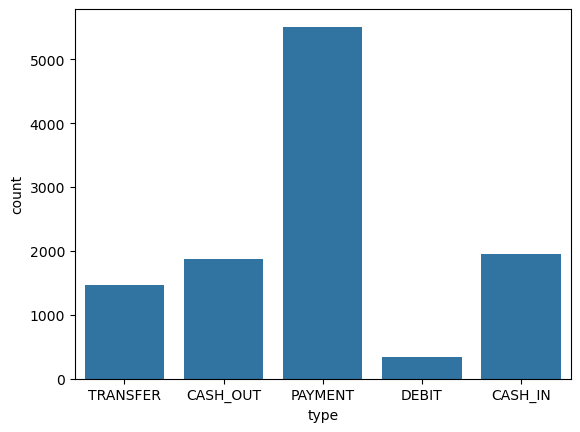

In [9]:
import seaborn as sns
sns.countplot(x='type',data=df)

<Axes: ylabel='amount'>

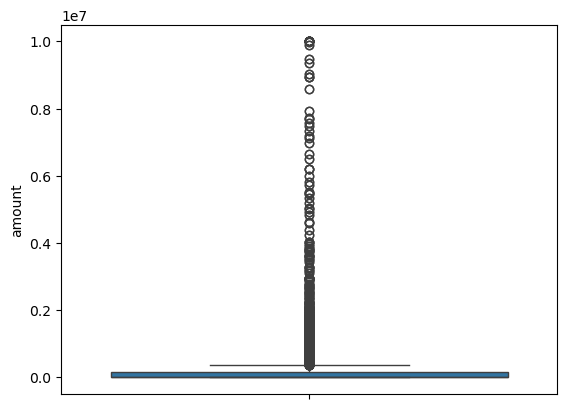

In [10]:
sns.boxplot(y=df['amount'])

In [11]:
df=df.drop(['nameOrig','nameDest','step'],axis=1)
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
2,TRANSFER,2806.00,2806.00,0.00,0.00,0.00,1
3,CASH_OUT,2806.00,2806.00,0.00,26202.00,0.00,1
4,TRANSFER,20128.00,20128.00,0.00,0.00,0.00,1


In [12]:
df=pd.get_dummies(df,drop_first=True,dtype='int')
df

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,181.00,0.00,0.00,0.00,1,0,0,0,1
1,181.00,181.00,0.00,21182.00,0.00,1,1,0,0,0
2,2806.00,2806.00,0.00,0.00,0.00,1,0,0,0,1
3,2806.00,2806.00,0.00,26202.00,0.00,1,1,0,0,0
4,20128.00,20128.00,0.00,0.00,0.00,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
11137,6393.71,433084.38,426690.68,478421.00,210535.25,0,0,1,0,0
11138,298799.54,426690.68,127891.14,704355.36,5270364.19,0,1,0,0,0
11139,423159.63,127891.14,0.00,610479.00,749621.53,0,1,0,0,0
11140,1094.03,13918.00,12823.97,0.00,0.00,0,0,0,1,0


In [13]:
x=df.drop('isFraud',axis=1)
y=df.isFraud

In [14]:
x

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,181.00,0.00,0.00,0.00,0,0,0,1
1,181.00,181.00,0.00,21182.00,0.00,1,0,0,0
2,2806.00,2806.00,0.00,0.00,0.00,0,0,0,1
3,2806.00,2806.00,0.00,26202.00,0.00,1,0,0,0
4,20128.00,20128.00,0.00,0.00,0.00,0,0,0,1
...,...,...,...,...,...,...,...,...,...
11137,6393.71,433084.38,426690.68,478421.00,210535.25,0,1,0,0
11138,298799.54,426690.68,127891.14,704355.36,5270364.19,1,0,0,0
11139,423159.63,127891.14,0.00,610479.00,749621.53,1,0,0,0
11140,1094.03,13918.00,12823.97,0.00,0.00,0,0,1,0


In [15]:
y

0        1
1        1
2        1
3        1
4        1
        ..
11137    0
11138    0
11139    0
11140    0
11141    0
Name: isFraud, Length: 11142, dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [17]:
x_scale=scaler.fit_transform(x)
x_scale

array([[-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       [-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27681175, -0.42993502, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       ...,
       [ 0.27626264, -0.37156334, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27906425, -0.42474954, -0.38861782, ..., -0.17902209,
         1.01101017, -0.38893563],
       [-0.26835212, -0.4125955 , -0.38005076, ..., -0.17902209,
         1.01101017, -0.38893563]], shape=(11142, 9))

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,random_state=70,test_size=0.3)

In [19]:
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [20]:
from imblearn.over_sampling import SMOTE

In [21]:
smt=SMOTE(random_state=42)
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

In [22]:
x_test_sm,y_test_sm=smt.fit_resample(x_test,y_test)

In [23]:
from lightgbm import LGBMClassifier

In [34]:
lgb=LGBMClassifier(n_estimators=10,learning_rate=0.3,random_state=42,max_depth=3)
lgb.fit(x_train_sm,y_train_sm)

TypeError: LGBMClassifier.__init__() takes 1 positional argument but 2 positional arguments (and 4 keyword-only arguments) were given

In [45]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,classification_report,confusion_matrix
y_pred_tt=lgb.predict(x_test)
y_pred_tr=lgb.predict(x_train)
acc_tt=accuracy_score(y_test,y_pred_tt)
acc_tr=accuracy_score(y_train,y_pred_tr)
print('accuracy for train',acc_tr)
print('accuracy for test',acc_tt)

accuracy for train 0.9966662392614438
accuracy for test 0.9889320969189351


C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [56]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lgb, x_train_sm, y_train_sm, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())


Cross-validation scores: [0.97997139 0.98462089 0.98319027 0.97817531 0.98783542]
Mean CV accuracy: 0.9827586559895174


In [ ]:
booster.dump_model()

In [41]:
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'accuracy',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_data_in_leaf': 20,
    'lambda_l1': 0.1,
    'lambda_l2': 0.5,
    'min_gain_to_split': 0.1,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbosity': -1
}


In [42]:
lgb=LGBMClassifier(n_estimators=100,**params)
lgb.fit(x_train_sm,y_train_sm)
#model = lgb.fit(params, lgb, n_estimators=200,objective='binary')

LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.9,
               lambda_l1=0.1, lambda_l2=0.5, learning_rate=0.05,
               metric='accuracy', min_data_in_leaf=20, min_gain_to_split=0.1,
               objective='binary', random_state=42, verbosity=-1)

In [43]:
cv_results = lgb.cv(
    params,
    lgb,
    nfold=5,
    num_boost_round=200,
    early_stopping_rounds=10,
    verbose_eval=False
)

best_round = len(cv_results['rmse-mean'])
print("Best iteration:", best_round)


AttributeError: 'LGBMClassifier' object has no attribute 'cv'

In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

model = LGBMRegressor()

param_grid = {
    'num_leaves': [31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'lambda_l1': [0, 0.1, 0.5],
    'lambda_l2': [0, 0.1, 0.5],
    'bagging_fraction': [0.8, 1.0],
    'feature_fraction': [0.8, 1.0],
}

grid = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1)
grid.fit(X, y)

print("Best parameters:", grid.best_params_)


In [57]:
booster = lgb.booster_
for i, t in enumerate(booster.dump_model()['tree_info']):
    print(f"Tree {i+1} leaf outputs:",
          [leaf['leaf_value'] for leaf in t['tree_structure']['leaf_value'] if isinstance(t['tree_structure'], dict)])

KeyError: 'leaf_value'

In [44]:
for i in range(1, xgb.n_estimators + 1):
    preds = xgb.predict(x_train, iteration_range=(0,i))
    acc = np.mean(preds == y_train)
    print(f"After tree {i}, train accuracy = {acc:.3f}")

After tree 1, train accuracy = 0.956
After tree 2, train accuracy = 0.960
After tree 3, train accuracy = 0.972
After tree 4, train accuracy = 0.973
After tree 5, train accuracy = 0.975
After tree 6, train accuracy = 0.977
After tree 7, train accuracy = 0.981
After tree 8, train accuracy = 0.987
After tree 9, train accuracy = 0.991
After tree 10, train accuracy = 0.990
After tree 11, train accuracy = 0.990
After tree 12, train accuracy = 0.991
After tree 13, train accuracy = 0.991
After tree 14, train accuracy = 0.992
After tree 15, train accuracy = 0.992
After tree 16, train accuracy = 0.993
After tree 17, train accuracy = 0.993
After tree 18, train accuracy = 0.994
After tree 19, train accuracy = 0.994
After tree 20, train accuracy = 0.995
After tree 21, train accuracy = 0.995
After tree 22, train accuracy = 0.995
After tree 23, train accuracy = 0.995
After tree 24, train accuracy = 0.996
After tree 25, train accuracy = 0.996
After tree 26, train accuracy = 0.996
After tree 27, train 

In [27]:
grid_params={
    'n_estimators':[10,50,100],
    'learning_rate':[0.1,0.5,1,10],
    'max_depth':[2,5,10],
    'subsample':[0.7,0.9,0.6],
    'colsample_bytree':[0.1,0.6,1],
    'gamma':[0,0.1,1],
    'reg_lambda':[1,5,10],
    'reg_alpha':[0,0.1,1]
}

In [34]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [36]:
rand=GridSearchCV(xgb,grid_params,cv=3,scoring='accuracy')
rand.fit(x_train_sm,y_train_sm)
print('best params',rand.best_params_)
print('best score',rand.best_score_)

best params {'colsample_bytree': 0.6, 'gamma': 0.1, 'learning_rate': 0.5, 'max_depth': 10, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 0.6}
best score 0.9944199253156857


In [37]:
xgb=XGBClassifier(n_estimators=100,learning_rate=0.5,gamma=0.1,random_state=42,max_depth=10,subsample=0.6,colsample_bytree=0.6,reg_alpha=0,reg_lambda=5,objective='binary:logistic')
xgb.fit(x_train_sm,y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,StratifiedKFold

In [26]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
gds=GridSearchCV(
    param_grid=grid_params,
    estimator=ab,
    verbose=2,n_jobs=-1,
    scoring='accuracy',
    cv=cv
)

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform  # Import from scipy.stats, not random

params_dist = {
    'n_estimators': randint(50, 301),    # scipy.stats.randint (50 to 300 inclusive)
    'learning_rate': uniform(0.1, 1.9)   # scipy.stats.uniform (0.1 to 2.0)
}

random_search = RandomizedSearchCV(
    estimator=ab,
    param_distributions=params_dist,
    scoring='accuracy',
    random_state=42,
    n_iter=20,
    cv=cv
)

random_search.fit(x_train, y_train)

print('Best score:', random_search.best_score_)
print('Best params:', random_search.best_params_)

C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorith

Best score: 0.9944866860742423
Best params: {'learning_rate': np.float64(1.9681386830328975), 'n_estimators': 298}


In [38]:
#from random import randint,uniform
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')
params_dist={
    'n_estimators':randint(50,301),
    'learning_rate':uniform(0.1,1.9)
}
random_search=RandomizedSearchCV(
    param_distributions=params_dist,
    estimator=ab,
    scoring='accuracy',
    random_state=42,
    n_iter=20,
    #cv=cv
)
random_search.fit(x_train_sm,y_train_sm)

print('print the best score',random_search.best_score_)
print('print the params',random_search.best_params_)

print the best score 0.9944197563091665
print the params {'learning_rate': np.float64(1.4453378978124864), 'n_estimators': 199}


In [36]:
gds.fit(x_train_sm,y_train_sm)
print('best score',gds.best_score_)
print('best params',gds.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


best score 0.9942767715699146
best params {'learning_rate': 1, 'n_estimators': 100}


In [44]:
y_pred_t=ab.predict(x_test)
y_pred_train=ab.predict(x_train)
print('test',y_pred_t)
print('train',y_pred_train)

NameError: name 'ab' is not defined

In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report
tt_acc=accuracy_score(y_test,y_pred_t)
print('test',tt_acc)
tr_acc=accuracy_score(y_train,y_pred_train)
print('train',tr_acc)

test 0.9880346993718218
train 0.9992306705987947


In [42]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(ab, x_train, y_train, cv=5, scoring='accuracy')
print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.98974359 0.97435897 0.98269231 0.98974359 0.98652983]
Mean CV Accuracy: 0.9846136576701042


In [45]:
#feature importance
importance=ab.feature_importances_
feature_importance=pd.Series(importance,index=x.columns).sort_values(ascending=True)
sorted_importance = feature_importance.sort_values(ascending=False)

print("Feature Importance:")
print(sorted_importance)


Feature Importance:
oldbalanceOrg    0.25
amount           0.23
newbalanceDest   0.17
oldbalanceDest   0.12
newbalanceOrig   0.10
type_PAYMENT     0.05
type_CASH_OUT    0.05
type_TRANSFER    0.01
type_DEBIT       0.01
dtype: float64


In [46]:
#Permutation importance
from sklearn.inspection import permutation_importance
results=permutation_importance(ab,x_train,y_train,random_state=42,n_repeats=10)
importance_df = pd.DataFrame({
 'feature': x.columns,   # column names
    'importance_mean': results.importances_mean,
    'importance_std': results.importances_std
}).sort_values(by="importance_mean", ascending=False)

print(importance_df)
print("="*7)
print(results.importances_mean)

          feature  importance_mean  importance_std
2  newbalanceOrig             0.15            0.00
1   oldbalanceOrg             0.15            0.00
7    type_PAYMENT             0.07            0.00
0          amount             0.05            0.00
3  oldbalanceDest             0.05            0.00
5   type_CASH_OUT             0.01            0.00
4  newbalanceDest             0.01            0.00
8   type_TRANSFER             0.00            0.00
6      type_DEBIT             0.00            0.00
[4.73009360e-02 1.47775356e-01 1.50814207e-01 4.59930760e-02
 1.09244775e-02 1.09885883e-02 5.12886267e-05 7.33170919e-02
 5.25708424e-04]


In [47]:
import shap
explainer=shap.TreeExplainer(ab)
shap_val=explainer.shap_values(x_train)
shap.summary_plot(shap_val,x_train)

ModuleNotFoundError: No module named 'shap'